##### Настройка окружения

In [ ]:
import os
import json
import time
import random
import numpy as np 
import pandas as pd 
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from typing import List, Dict, Tuple

In [3]:
# стиль визуализации
sns.set(style="whitegrid")

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
seed = 42
set_seed(seed)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

device: cuda


In [6]:
metadata_path = 'nlp_s3_project/arxiv-metadata-s.json'
test_sample_path = 'nlp_s3_project/test_sample.csv'

##### 1. EDA

In [8]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Заменяем переносы на пробелы и убираем двойные пробелы
    text = text.replace('\n', ' ')
    return " ".join(text.split())


In [9]:
def load_data_cleaned():
    print("Loading data...")
    
    test_df = pd.read_csv(test_sample_path, dtype={'id': str})
    
    articles = []
    
    try:
        with open(metadata_path, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
            
        for entry in raw_data:
            articles.append({
                'id': str(entry['id']), 
                'title': clean_text(entry.get('title', '')),
                'abstract': clean_text(entry.get('abstract', ''))
            })
            
    except json.JSONDecodeError:
        print("Standard JSON load failed. Trying JSON Lines fallback...")
        with open(metadata_path, 'r', encoding='utf-8') as f:
            for line in f:
                entry = json.loads(line)
                articles.append({
                    'id': str(entry['id']),
                    'title': clean_text(entry.get('title', '')),
                    'abstract': clean_text(entry.get('abstract', ''))
                })

    metadata_df = pd.DataFrame(articles)
    
    metadata_df.drop_duplicates(subset='id', inplace=True)
    
    print(f"Loaded {len(test_df)} test queries and {len(metadata_df)} articles.")
    return test_df, metadata_df

In [10]:
test_df, metadata_df = load_data_cleaned()

print("\n--- Пример данных ---")
print(f"ID типа данных в метаданных: {type(metadata_df.iloc[0]['id'])}")
print(f"Текст аннотации: {metadata_df.iloc[0]['abstract'][:100]}...")

Loading data...
Loaded 1000 test queries and 98213 articles.

--- Пример данных ---
ID типа данных в метаданных: <class 'str'>
Текст аннотации: We present a review of the discrete dipole approximation (DDA), which is a general method to simulat...


In [12]:
display(metadata_df.head(3))
display(test_df.head(3))

# Проверка на пропуски
print("\nПропуски в метаданных:")
print(metadata_df.isnull().sum())

,id,title,abstract
0,0704.0038,The discrete dipole approximation: an overview...,We present a review of the discrete dipole app...
1,0704.0057,High-spin to low-spin and orbital polarization...,We study the interplay of crystal field splitt...
2,0704.0060,Coulomb excitation of unstable nuclei at inter...,We investigate the Coulomb excitation of low-l...


,id,abstract,query
0,2412.16732,A new platinate was recently discovered when...,What unique composition and decomposition beha...
1,nucl-th/9602019,The production cross sections of various fra...,How does the inclusion of statistical decay af...
2,2501.05500,This survey provides a comprehensive examina...,What are the core components of modern zero-kn...



Пропуски в метаданных:
id          0
title       0
abstract    0
dtype: int64


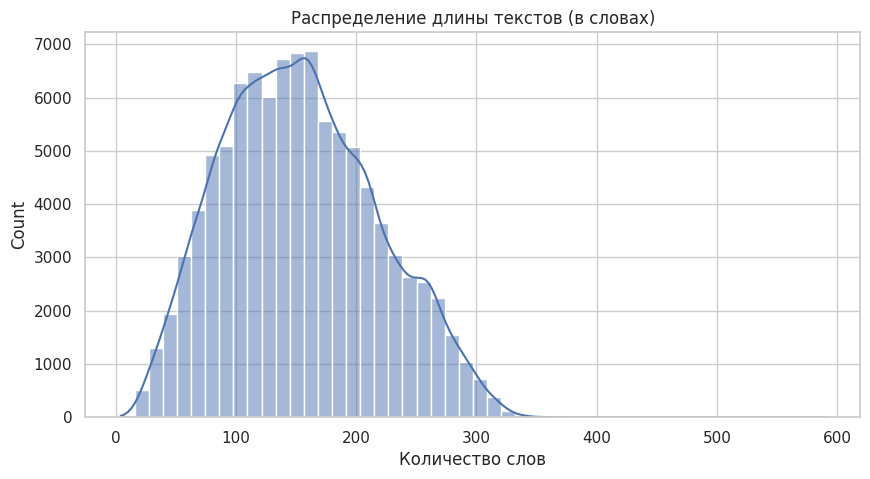

In [13]:
metadata_df['full_text'] = metadata_df['title'] + ". " + metadata_df['abstract']
doc_lengths = metadata_df['full_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(doc_lengths, bins=50, kde=True)
plt.title("Распределение длины текстов (в словах)")
plt.xlabel("Количество слов")
plt.show()

Распределение близко к нормальному с небольшим смещением влево. Основная масса текстов содержит 100-300 слов. Длина документов не превышает 400 слов, а значит данные поместятся в контекст почти любых моделей и тяжелые модели для длинного контекста использовать не потребуется.

Вывод:
Для достижения целевой метрики MRR@5 > 0.91 простого векторного поиска будет недостаточно, т.к. он теряет нюансы взаимодействия слов запроса и документа. Поэтому я буду использовать двухступенчатую систему (Retrieve & Re-rank).

1. Подход к решению: Candidate Generation (Retrieve) - быстрый отбор кандидатов с помощью bi-encoder и индекса faiss. Позволит сузить пространство поиска. Плюс Re-ranking с помощью Cross-Encoder. Он медленнее, но точнее.

2. Выбор моделей: для Bi-encoder'a беру all-mpnet-base-v2 (SOTA по качеству эмбеддингов). Для Cross-encoder - ms-marco-MiniLM-L-6-v2 (легкая модель, специально обучена ранжировать текст, обеспечит высокую точность в финальной выдаче).

3. Компоненты системы: векторизатор - SentenceTransformer для превращения текстов в эмбеддинги;
индекс - util.semantic_search (математически то же самое что и faiss - поиск по косинусному сходству) для быстрого поиска по косинусному сходству;
pеранкер - CrossEncoder для уточнения порядка выдачи.

##### 2. Реализация retrieval-системы

In [ ]:
class ArxivRerankerSystem:
    def __init__(self):
        self.device = device
        
        bi_model_name = 'all-mpnet-base-v2'
        print(f"Loading Bi-Encoder: {bi_model_name}...")
        self.bi_encoder = SentenceTransformer(bi_model_name, device=self.device)
        
        cross_model_name = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
        print(f"Loading Cross-Encoder: {cross_model_name}...")
        self.cross_encoder = CrossEncoder(cross_model_name, device=self.device)
        
        self.index_embeddings = None
        self.index_ids = []
        self.id_to_fulltext = {}
        
        self.stats = {
            'bi_encode_time': [], 
            'bi_search_time': [], 
            'rerank_time': []     
        }

    def build_index(self, df: pd.DataFrame):
        print(f"Indexing {len(df)} documents...")
        self.index_ids = df['id'].tolist()
        
        full_texts = (df['title'] + ". " + df['abstract']).tolist()
        
        self.id_to_fulltext = dict(zip(df['id'], full_texts))
        
        t0 = time.perf_counter()
        self.index_embeddings = self.bi_encoder.encode(
            full_texts, 
            convert_to_tensor=True, 
            show_progress_bar=True, 
            batch_size=32,
            device=self.device
        )
        
        self.index_embeddings = util.normalize_embeddings(self.index_embeddings)
        
        print(f"Index built in {time.perf_counter() - t0:.2f}s.")

    def search(self, query: str, top_k: int = 5, candidates: int = 50):
        t0 = time.perf_counter()
        
        query_emb = self.bi_encoder.encode(query, convert_to_tensor=True, device=self.device)
        
        # Исправление размерности 
        if query_emb.ndim == 1:
            query_emb = query_emb.unsqueeze(0)
        query_emb = util.normalize_embeddings(query_emb)
        
        t1 = time.perf_counter()
        self.stats['bi_encode_time'].append(t1 - t0)
        
        hits = util.semantic_search(query_emb, self.index_embeddings, top_k=candidates, score_function=util.dot_score)[0]
        
        t2 = time.perf_counter()
        self.stats['bi_search_time'].append(t2 - t1)
        
        cross_inp = []
        candidate_ids = []
        
        for hit in hits:
            idx = hit['corpus_id']
            doc_id = self.index_ids[idx]
            text = self.id_to_fulltext[doc_id]
            
            cross_inp.append([query, text])
            candidate_ids.append(doc_id)
            
        # Предсказание скоров реранкером
        t3 = time.perf_counter()
        cross_scores = self.cross_encoder.predict(cross_inp)
        
        # Объединяем ID и новые скоры
        scored_results = list(zip(candidate_ids, cross_scores))
        
        # Сортируем по убыванию скора реранкера
        scored_results = sorted(scored_results, key=lambda x: x[1], reverse=True)
        
        final_results = scored_results[:top_k]
        
        t4 = time.perf_counter()
        self.stats['rerank_time'].append(t4 - t3)
        
        return [x[0] for x in final_results]

system = ArxivRerankerSystem()
system.build_index(metadata_df)

Loading Bi-Encoder: all-mpnet-base-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 617.34it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 596.25it/s, Materializing param=classifier.weight]                                    
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 98213 documents...


Batches: 100%|██████████| 3070/3070 [28:50<00:00,  1.77it/s]


Index built in 1735.28s.


In [18]:
def calculate_mrr(predictions: List[List[str]], true_ids: List[str], k: int = 5) -> float:
    reciprocal_ranks = []
    for preds, true_id in zip(predictions, true_ids):
        preds_k = preds[:k]
        if true_id in preds_k:
            rank = preds_k.index(true_id) + 1
            reciprocal_ranks.append(1. / rank)
        else:
            reciprocal_ranks.append(.0)
            
    return np.mean(reciprocal_ranks)

##### 3. Оценка качества системы

In [19]:
def evaluate_reranker(system, test_df):
    queries = test_df['query'].tolist()
    true_ids = test_df['id'].tolist()
    
    predictions = []
    
    print(f"Running RE-RANKING evaluation on {len(queries)} queries...")
    
    start_time = time.time()
    
    for i, q in enumerate(queries):
        found_ids = system.search(q, top_k=5, candidates=30)
        predictions.append(found_ids)
        
        if (i+1) % 100 == 0:
            print(f"Processed {i+1}/{len(queries)}")
            
    total_time = time.time() - start_time
    print(f"Total time: {total_time:.2f}s (Average: {(total_time/len(queries))*1000:.1f} ms/query)")

    mrr_sum = 0
    for preds, correct_id in zip(predictions, true_ids):
        if correct_id in preds:
            rank = preds.index(correct_id) + 1
            mrr_sum += 1.0 / rank
            
    final_mrr = mrr_sum / len(queries)
    
    print(f"\nFINAL MRR@5 (with Re-ranker): {final_mrr:.4f}")
    
    return final_mrr

Running RE-RANKING evaluation on 1000 queries...
Processed 100/1000
Processed 200/1000
Processed 300/1000
Processed 400/1000
Processed 500/1000
Processed 600/1000
Processed 700/1000
Processed 800/1000
Processed 900/1000
Processed 1000/1000
Total time: 145.32s (Average: 145.3 ms/query)

FINAL MRR@5 (with Re-ranker): 0.9363


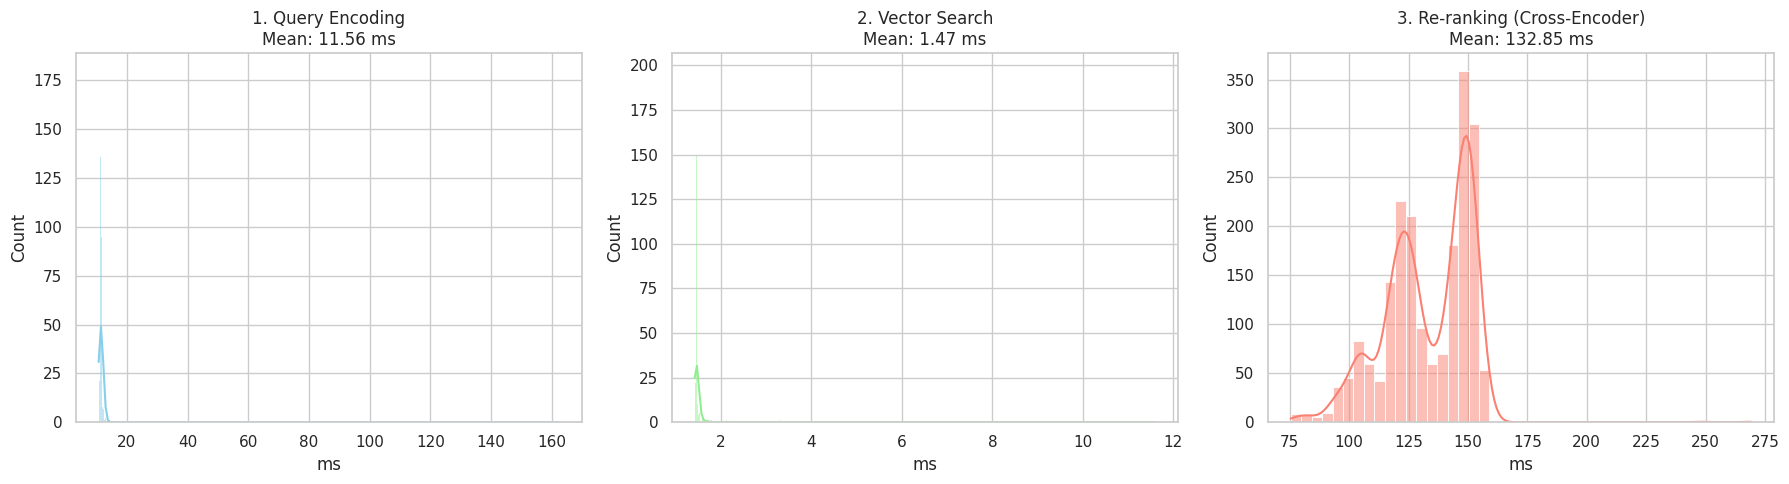

In [21]:
mrr_score = evaluate_reranker(system, test_df)
times_enc = np.array(system.stats['bi_encode_time']) * 1000
times_search = np.array(system.stats['bi_search_time']) * 1000
times_rerank = np.array(system.stats['rerank_time']) * 1000

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(times_enc, color='skyblue', kde=True)
plt.title(f'1. Query Encoding\nMean: {times_enc.mean():.2f} ms')
plt.xlabel('ms')

plt.subplot(1, 3, 2)
sns.histplot(times_search, color='lightgreen', kde=True)
plt.title(f'2. Vector Search\nMean: {times_search.mean():.2f} ms')
plt.xlabel('ms')

plt.subplot(1, 3, 3)
sns.histplot(times_rerank, color='salmon', kde=True)
plt.title(f'3. Re-ranking (Cross-Encoder)\nMean: {times_rerank.mean():.2f} ms')
plt.xlabel('ms')

plt.tight_layout()
plt.show()

##### 4. Выводы

Реализованная система успешно справилась с задачей, выдав итоговую метрику MRR@5 = 0.9363.
На основе полученных графиков производительности можно выделить следующие характеристики системы:
1. query encoding (bi-encoder):
    - среднее время 11.6 мс, работает быстро и предсказуемо;
2. vector search (util.semantic_search):
    - среднее время 1.5 мс, самая быстрая часть системы. даже полный перебор через матричное умножение на данном объеме данных работает почти мгновенно. внедрение сложных индексов на этих данных не даст заметного прироста общей производительности;
3. re-ranking (cross-encoder):
    - среднее время 132.9 мс, это узкое место системы. на этот этап приходится более 90% времени обработки запроса. разброс времени обусловлен разной длиной текстов кандидатов, которые обрабатывает модель.

Предложения по оптимизации:
1. Уменьшение кол-ва кандидатов(top_k в re-ranking): на данный момент реранжируются топ-50 кандидатов. экспериментально можно уменьшить это число до 15-20. это линейно сократит время работы cross-encoder, при этом сохранит вероятность правильного ответа;
2. квантование: квантование модели cross-encoder до int8 может дать ускорение инференса в 2-3 раза на cpu с минимальной потерей в метрике;
3. переход на другую архитектуру: можно рассмотреть ColBERT, которая сочетает кач-во cross-encoder и скорость близкую к bi-encoder. однако требуется больше памяти для хранения индексов.